In [2]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

In [3]:
#Load the tables from prostgreSQL data base
user = 'postgres'
password = 'sql2026'
host = 'localhost'
port = '5432'
database = 'churn_analysis'

#connect with the data base
engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")

#Queries
#Load the account_info table
query_1 = "SELECT * FROM account_info"
account_info = pd.read_sql(query_1, engine)

#Load the customer_support table
query_2 = "SELECT * FROM customer_support"
customer_support = pd.read_sql(query_2, engine)

#Load user_activity table
query_3 = "SELECT * FROM user_activity"
user_activity = pd.read_sql(query_3, engine)

In [4]:
#View of account_info df
account_info.head()

,user_id,email,state,plan,plan_list_price,churn_status
0,10000,user10000@example.com,New Jersey,Enterprise,105,Yes
1,10001,user10001@example.net,Louisiana,Basic,22,Yes
2,10002,user10002@example.net,Oklahoma,Basic,24,No
3,10003,user10003@example.com,Michigan,Free,0,No
4,10004,user10004@example.com,Texas,Enterprise,119,No


In [5]:
#View of customer_suport df
customer_support.head()

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments,state_label
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,unknown,Solved
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,unknown,Open
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.,Open
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,unknown,Solved
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,unknown,Solved


In [6]:
#View of user_activity df
user_activity.head()

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch video
1,2025-09-08 08:15:05.264103,10220,watch video
2,2025-11-14 06:28:35.207671,10009,share workout
3,2025-08-20 16:53:38.682901,10227,read article
4,2025-07-24 16:47:31.728422,10123,track workout


### UNIVARIATE ANALYSIS

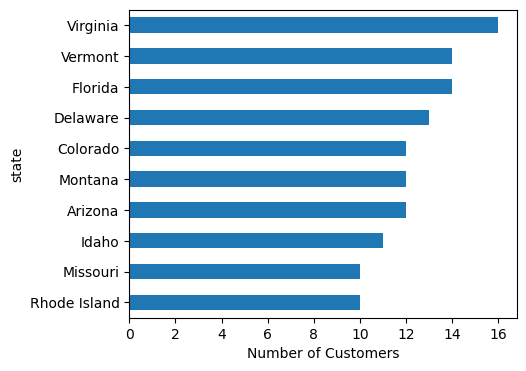

In [7]:
#Top 10 states by number of customers
top_states = account_info['state'].value_counts()
top_states = top_states.head(10).sort_values(ascending = True)
#print(top_states)

#Bar graph
plt.figure(figsize=(5, 4))
top_states.plot(kind='barh')
plt.xlabel('Number of Customers')
plt.show()

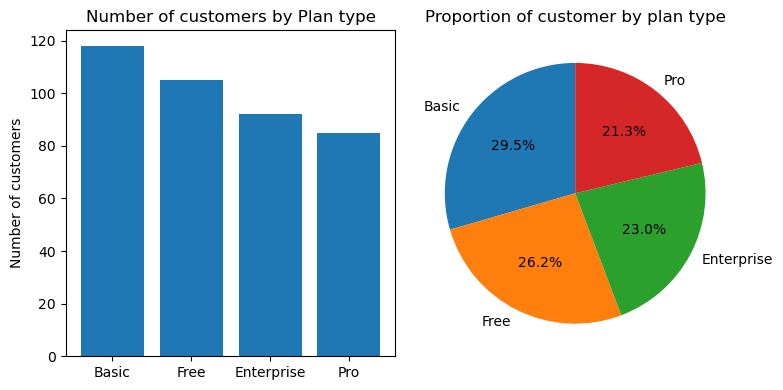

In [8]:
#Number of customers by plan type
num_plan = account_info['plan'].value_counts()
num_plan.sort_values(ascending=False, inplace= True)
#Layout
fig, ax = plt.subplots(1, 2, figsize = (8, 4))
#Bar chart
ax[0].bar(x = num_plan.index, height = num_plan.values)
ax[0].set_title('Number of customers by Plan type')
ax[0].set_ylabel('Number of customers')

#Pie chart
ax[1].pie(x = num_plan.values, labels = num_plan.index, autopct = '%1.1f%%', startangle = 90)
ax[1].set_title('Proportion of customer by plan type')
#show
plt.tight_layout()
plt.show()



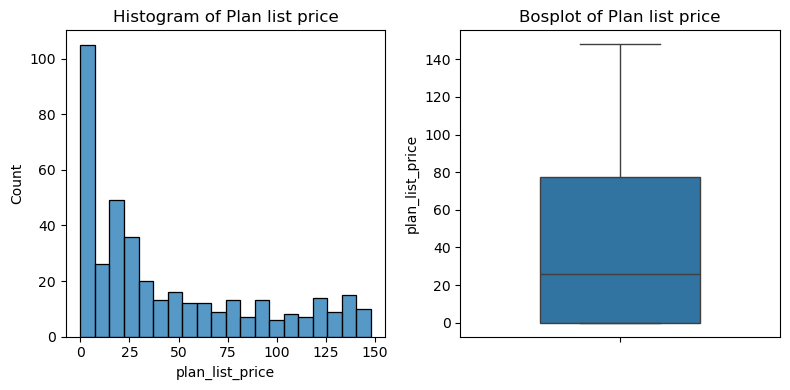

In [9]:
#Distribution of plan list price
#Layout
fig1, ax1 = plt.subplots(1, 2, figsize = (8, 4))

#Histogram
sns.histplot(data = account_info, x = 'plan_list_price', ax = ax1[0], bins = 20)
ax1[0].set_title('Histogram of Plan list price')

#Boxplot
sns.boxplot(data = account_info, y = 'plan_list_price', ax = ax1[1], width = 0.5)
ax1[1].set_title('Bosplot of Plan list price')

#Show
plt.tight_layout()
plt.show()


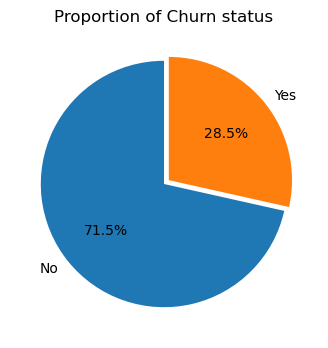

In [10]:
#Proportion of churn status
num_churn = account_info['churn_status'].value_counts()

#pie chart
plt.figure(figsize=(4, 4))
plt.pie(x = num_churn.values, labels = num_churn.index, autopct = "%1.1f%%", startangle = 90, explode = (0, 0.05))
plt.title('Proportion of Churn status')
plt.show()

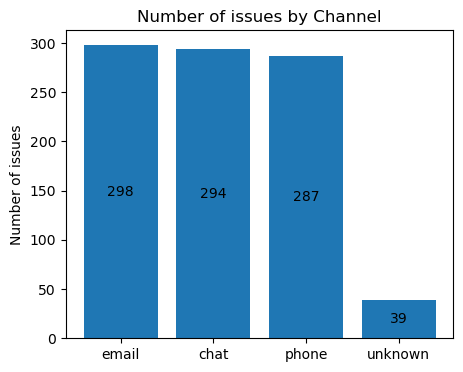

In [11]:
#Number of issues reported by channel
num_channel = customer_support['channel'].value_counts().sort_values(ascending= False)

#Bar chart
plt.figure(figsize=(5, 4))
g = plt.bar(x = num_channel.index, height=  num_channel.values)
plt.title('Number of issues by Channel')
plt.ylabel('Number of issues')
plt.bar_label(g, label_type='center')
plt.show()

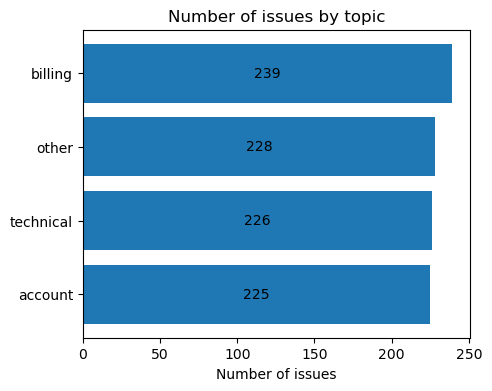

In [12]:
#Number of issues by topic
num_topic = customer_support['topic'].value_counts().sort_values(ascending= True)

#Bar chart
plt.figure(figsize = (5, 4))
g1 = plt.barh(y = num_topic.index, width = num_topic.values)
plt.title('Number of issues by topic')
plt.xlabel('Number of issues')
plt.bar_label(g1, label_type='center')
plt.show()

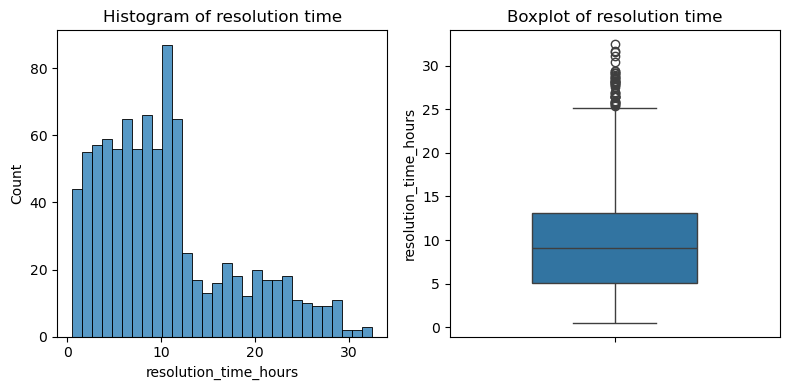

In [13]:
#Distribution of resolution time hours
#layout configuration
fig2, ax2 = plt.subplots(1, 2, figsize = (8, 4))

#Histogram
sns.histplot(data = customer_support, x = 'resolution_time_hours', ax = ax2[0], bins = 30)
ax2[0].set_title('Histogram of resolution time')

#Boxplot
sns.boxplot(data= customer_support, y = 'resolution_time_hours', ax = ax2[1], width=0.5)
ax2[1].set_title('Boxplot of resolution time')
#Show
plt.tight_layout()
plt.show()

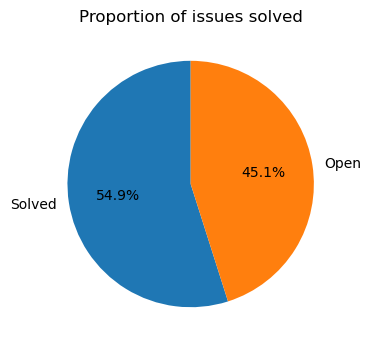

In [14]:
#Proportion of issues solved
num_issue = customer_support['state_label'].value_counts()

#pie chart
plt.figure(figsize=(4, 4))
plt.pie(x = num_issue.values, labels = num_issue.index, startangle = 90, autopct = '%1.1f%%')
plt.title('Proportion of issues solved')
plt.show()

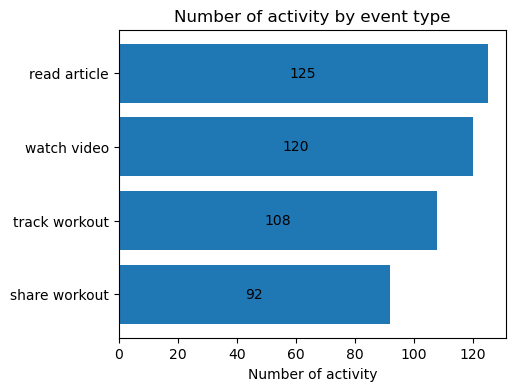

In [15]:
#Number of activity by event type
num_event = user_activity['event_type'].value_counts().sort_values(ascending=True)

#Bar chart
plt.figure(figsize=(5, 4))
g3 = plt.barh(y = num_event.index, width = num_event.values)
plt.bar_label(g3, label_type='center')
plt.title('Number of activity by event type')
plt.xlabel('Number of activity')
plt.show()

### BINARY ANALYSIS

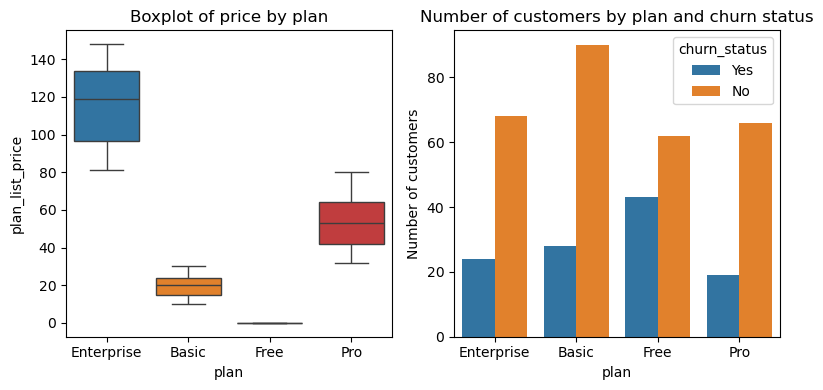

In [ ]:
#Account info table
#Set layout
fig3, ax3 = plt.subplots(1, 2, figsize = (8, 4))

#Plan list price by plan
sns.boxplot(data = account_info, x = 'plan', y = 'plan_list_price', ax = ax3[0], hue = 'plan')
ax3[0].set_title('Boxplot of price by plan')

#Number of customer by plan and churn status
sns.countplot(data = account_info, x = 'plan', hue = 'churn_status', ax  =ax3[1])
ax3[1].set_title('Number of customers by plan and churn status')
ax3[1].set_ylabel('Number of customers')
#Show
plt.tight_layout()
plt.show()

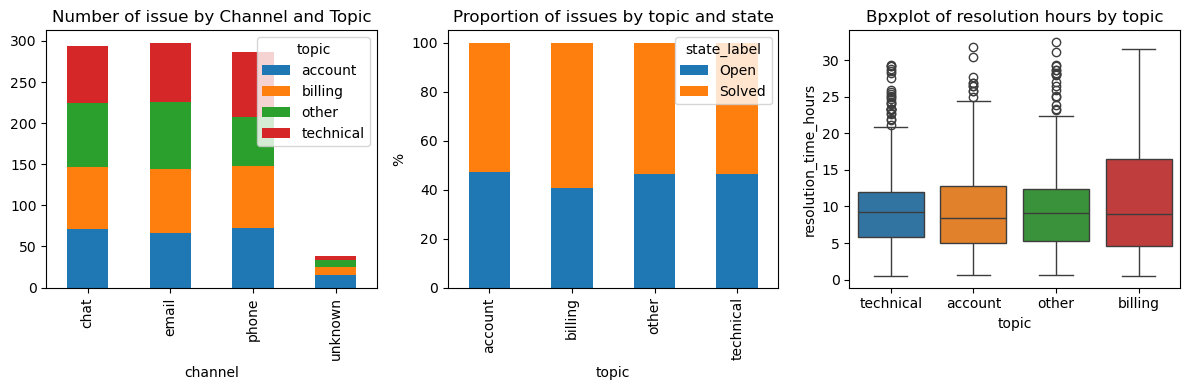

In [33]:
#Customer support table
#Set the layout
fig4, ax4 = plt.subplots(1, 3, figsize = (12, 4))

#NUmber of issues by channel and topic
pivot = pd.pivot_table(data = customer_support, index = 'channel', columns = 'topic', values='user_id', aggfunc='count')
pivot.plot(kind = 'bar', stacked = True, ax = ax4[0])
ax4[0].set_title('Number of issue by Channel and Topic')

#Number of issues by topic and state
pivot_state = pd.pivot_table(data = customer_support, index = 'topic', columns = 'state_label', values = 'user_id', aggfunc='count')
pivot_state_pct = pivot_state.div(pivot_state.sum(axis = 1), axis = 0)*100
pivot_state_pct.plot(kind = 'bar', stacked = True, ax = ax4[1])
ax4[1].set_title('Proportion of issues by topic and state')
ax4[1].set_ylabel('%')

#Boxplot of resolution time hours by topic
sns.boxplot(data = customer_support, x = 'topic', y = 'resolution_time_hours', hue = 'topic', ax  =ax4[2])
ax4[2].set_title('Bpxplot of resolution hours by topic')
#Show
plt.tight_layout()
plt.show()

(918, 13)
(445, 8)


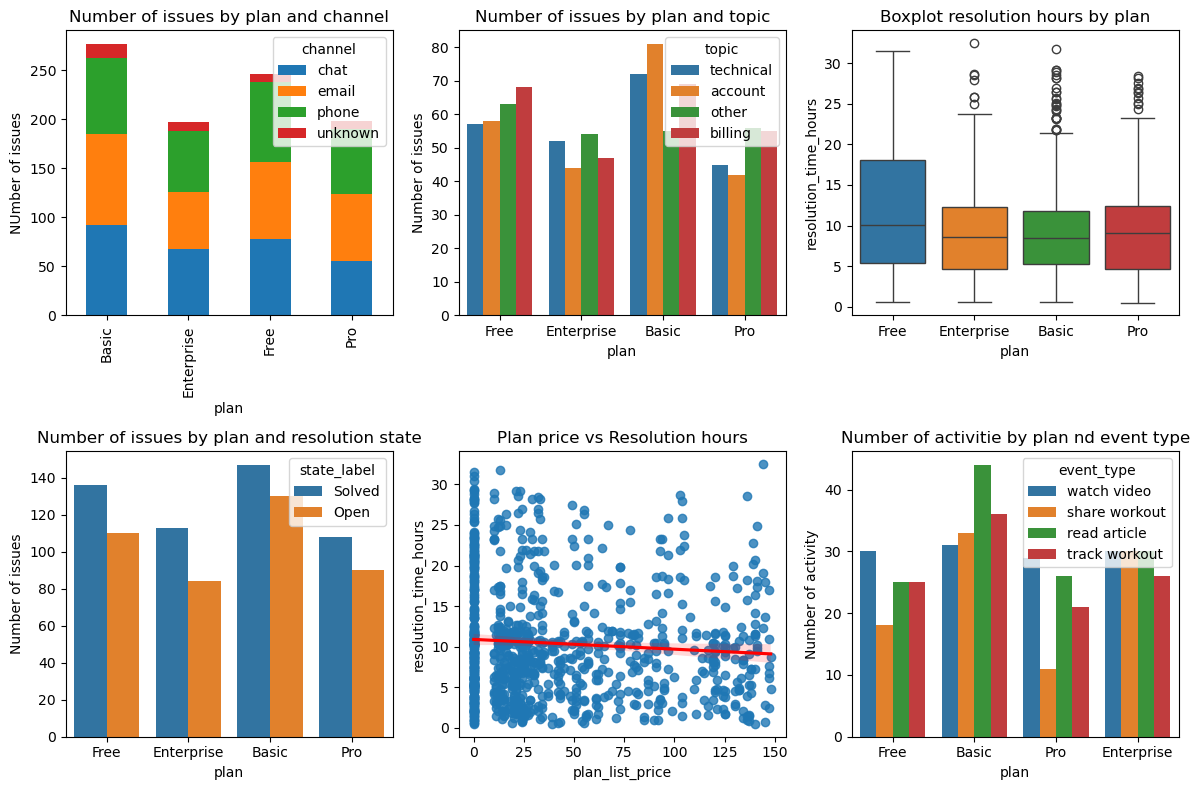

In [61]:
#Merge customer_support with account_info df
support_account = pd.merge(customer_support, account_info, on='user_id', how='left')
print(support_account.shape)

#Merge user_activity with account_info df
activity_account  = pd.merge(user_activity, account_info, on = 'user_id', how = 'left')
print(activity_account.shape)

#Set the layout
fig5, ax5 = plt.subplots(2, 3, figsize = (12, 8))

#Number of issues by plan and channel
pivot_channel = pd.pivot_table(support_account, index = 'plan', \
                               columns = 'channel', values = 'user_id', aggfunc='count')
pivot_channel.plot(kind='bar', stacked=True, ax  =ax5[0,0])
ax5[0,0].set_title('Number of issues by plan and channel')
ax5[0, 0].set_ylabel('NUmber of issues')

#Number of issues by plan and topic
sns.countplot(data = support_account, x  ='plan', hue = 'topic', ax = ax5[0, 1])
ax5[0, 1].set_title('Number of issues by plan and topic')
ax5[0, 1].set_ylabel('Number of issues')

#Resolution time hours by plan
sns.boxplot(data = support_account, x = 'plan', y = 'resolution_time_hours', hue = 'plan', ax = ax5[0, 2])
ax5[0, 2].set_title('Boxplot resolution hours by plan')

#Number of issues by plan and state label
sns.countplot(data = support_account, x = 'plan', hue = 'state_label', ax  =ax5[1, 0])
ax5[1, 0].set_title('Number of issues by plan and resolution state')
ax5[1, 0].set_ylabel('Number of issues')

#Correlation of plat list price vs resolution time hours
sns.regplot(data=support_account, x = 'plan_list_price', y = 'resolution_time_hours', \
            ax = ax5[1,1], line_kws= {'color':'red'})
ax5[1, 1].set_title('Plan price vs Resolution hours')

#NUmber of activities by plan and event type
sns.countplot(data=activity_account, x = 'plan', hue = 'event_type', ax = ax5[1,2])
ax5[1, 2].set_title('Number of activitie by plan nd event type')
ax5[1, 2].set_ylabel('Number of activity')

#tight and show
plt.tight_layout()
plt.show()

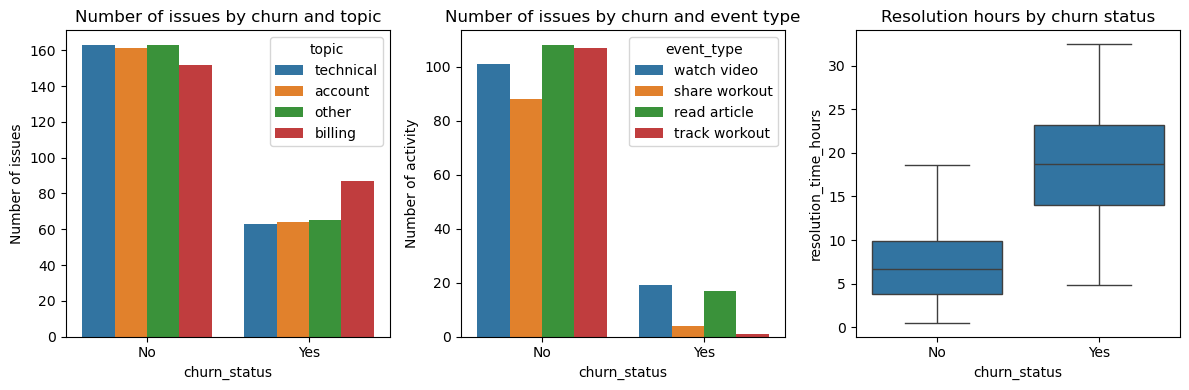

In [69]:
#Interaction of churn status and other variables

#set the layout
fig6, ax6 = plt.subplots(1, 3, figsize = (12, 4))

#NUmber of issues by churn status and topic
sns.countplot(data = support_account, x = 'churn_status', hue = 'topic', ax = ax6[0])
ax6[0].set_title('Number of issues by churn and topic')
ax6[0].set_ylabel('Number of issues')

#Number of activity by churn status and event type
sns.countplot(data = activity_account, x = 'churn_status', hue = 'event_type', ax = ax6[1])
ax6[1].set_title('Number of issues by churn and event type')
ax6[1].set_ylabel('Number of activity')

#Resolution time hour by churn status
sns.boxplot(data = support_account, x = 'churn_status', y = 'resolution_time_hours', ax = ax6[2])
ax6[2].set_title('Resolution hours by churn status')

#show
plt.tight_layout()
plt.show()